# Palm Cohort Supplement  Derma Dataset (HuggingFace, Body_part-filterable)

Supplements 4 existing GLANCE Palm Cohort categories (Vitiligo, Psoriasis,
Eczema, Scabies) with additional hand/palm/wrist/finger-confirmed clinical
images, sourced via metadata filtering rather than manual visual triage.

**Dataset:** [sharl-008/derma-dataset — HuggingFace](https://huggingface.co/datasets/sharl-008/derma-dataset)

5,444 professionally-graded clinical images (233 disease labels), each
with an explicit `Body_part` field, `Quality`/`Confidence` ratings, and
Fitzpatrick/Monk skin-tone metadata. No authentication/token required
(public dataset).

## What this notebook does

1. **Load dataset** via HuggingFace `datasets` library (train + test
   splits combined, 5,444 rows total).

2. **Filter by Body_part metadata**  selected rows where `Body_part`
   contains Hand/Palm/Wrist/Finger keywords: 450 images matched. This
   replaces the manual visual-triage process used in earlier Palm
   notebooks (Vitiligo/Psoriasis), since this dataset provides
   ground-truth location metadata directly.

3. **Map disease labels to existing categories**  merged label
   variants (e.g. "Scabies Infected", "Pustular Scabies" -> Scabies)
   and kept only the 4 categories with meaningful volume (10+ images)
   that match existing Palm Cohort notebooks:
   - Vitiligo: 124
   - Scabies (+ Infected + Pustular): 61
   - Eczema (+ Infected + Disseminated): 49
   - Psoriasis (+ Palmar + Chronic plaque + Guttate + Pustular): 21

   Smaller candidate categories (Onychomycosis, Contact Dermatitis,
   Tinea Manuum, Palmoplantar Keratoderma, Wart, Tinea Corporis, Lichen
   Planus — all under 30 images) were intentionally excluded per team
   decision to focus on strengthening existing categories rather than
   fragmenting into many small new ones.

4. **Decode and save images**  HuggingFace's image column stores
   images as byte dictionaries; decoded via PIL and saved as JPG files
   to disk, organized into class folders.

5. **Visual verification**  confirmed all 4 classes show genuine
   hand/palm/wrist location images. Note: some images include partial
   forearm/upper-arm context alongside the hand (expected, since
   several source rows have combined Body_part labels like
   "Forearm,Hand")  accepted as clinically normal framing, not a
   labeling error.

6. **Artifact check**  0% black-border artifact across all 4 classes.

7. **Resize to 224x224 + save final CSV.**

**Status:** This is a supplement dataset, held pending merge. Once all
Palm Cohort notebooks (1-5) are finalized, this will be combined with
each category's original notebook output, with a `source_dataset`
column added for traceability.

**Final output:** `filtered_df` (255 images) with `final_path_224`
column at `/kaggle/working/derma_handpalm_supplement_224/`, saved as
`/kaggle/working/derma_handpalm_supplement_clean.csv`.

In [2]:
#Step 0 — Load HuggingFace Dataset (train + test, combined)
!pip install datasets --quiet

DATASET_META = {
    "dataset_name": "Derma Dataset (sharl-008, HuggingFace) - Body_part filterable",
    "dataset_url": "https://huggingface.co/datasets/sharl-008/derma-dataset",
    "hf_path": "sharl-008/derma-dataset",
    "surface": "Hand/Palm"
}

from datasets import load_dataset
import pandas as pd

ds = load_dataset(DATASET_META["hf_path"])
print(ds)

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()
df_all = pd.concat([train_df, test_df], ignore_index=True)
print(f"\nTotal rows: {len(df_all)}")
print(f"\nBody_part unique values containing 'Hand' or 'Palm':")
hand_mask = df_all["Body_part"].str.contains("Hand|Palm|Wrist|Finger", case=False, na=False)
print(f"Matching rows: {hand_mask.sum()}")
print(df_all[hand_mask]["Body_part"].value_counts())

README.md:   0%|          | 0.00/998 [00:00<?, ?B/s]

data/train-00000-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  438MB            

data/train-00000-of-00007.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  427MB            

data/train-00001-of-00007.parquet: downloading bytes:           |  0.00B            

...

data/test-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  336MB            

data/test-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4355 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1089 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Age', 'Body_part', 'Descriptors', 'Confidence', 'Disease_label', 'Fitzpatrick', 'Gradability', 'Image_name', 'Main_class', 'Monk_skin_tone', 'Quality', 'Sex', 'Sub_class', 'Subject_ID', 'image'],
        num_rows: 4355
    })
    test: Dataset({
        features: ['Age', 'Body_part', 'Descriptors', 'Confidence', 'Disease_label', 'Fitzpatrick', 'Gradability', 'Image_name', 'Main_class', 'Monk_skin_tone', 'Quality', 'Sex', 'Sub_class', 'Subject_ID', 'image'],
        num_rows: 1089
    })
})

Total rows: 5444

Body_part unique values containing 'Hand' or 'Palm':
Matching rows: 450
Body_part
Upper Extremities Hands (Manus) Fingers (Digits)                                                                                                                                                                                                      196
Palms                                                                                              

In [3]:
#Step 1 — Filter by Body_part Metadata (Hand/Palm/Wrist/Finger)
hand_df = df_all[hand_mask].copy()

print("Disease breakdown in hand/palm-confirmed images:")
print(hand_df["Disease_label"].value_counts())

print(f"\nTotal: {len(hand_df)} images")

Disease breakdown in hand/palm-confirmed images:
Disease_label
Vitiligo                      124
Scabies                        40
Eczema                         38
Onychomycosis                  22
Contact Dermatitis             22
                             ... 
Hyper Hydrosis                  1
Bullous Pemphigoid              1
Granuloma pyogenic              1
Hyperpigmentation disorder      1
Itchy skin eruption             1
Name: count, Length: 67, dtype: int64

Total: 450 images


In [4]:
#Step 2 — Map Disease Labels to Existing Categories (Vitiligo/Scabies/Eczema/Psoriasis)
category_map = {
    "Vitiligo": ["Vitiligo"],
    "Scabies": ["Scabies", "Scabies Infected", "Pustular Scabies"],
    "Eczema": ["Eczema", "Infected Eczema", "Disseminated Eczema"],
    "Psoriasis": ["Psoriasis", "Palmar psoriasis", "Chronic plaque psoriasis", "Guttate Psoriasis", "Pustular psoriasis"],
}

reverse_map = {label: cat for cat, labels in category_map.items() for label in labels}
hand_df["merged_class"] = hand_df["Disease_label"].map(reverse_map)
filtered_df = hand_df[hand_df["merged_class"].notna()].reset_index(drop=True)

print(f"Filtered dataset: {len(filtered_df)} images")
print(filtered_df["merged_class"].value_counts())

Filtered dataset: 255 images
merged_class
Vitiligo     124
Scabies       61
Eczema        49
Psoriasis     21
Name: count, dtype: int64


In [5]:
#Step 4 — Decode & Save Images (HuggingFace Bytes -> JPG Files)
from pathlib import Path
from PIL import Image
import io

OUTPUT_DIR = Path("/kaggle/working/derma_handpalm_supplement")

final_paths = []
failed = []

for idx, row in filtered_df.iterrows():
    cls_dir = OUTPUT_DIR / row["merged_class"]
    cls_dir.mkdir(parents=True, exist_ok=True)

    img_data = row["image"]
    try:
        if isinstance(img_data, dict):
            img = Image.open(io.BytesIO(img_data["bytes"]))
        else:
            img = img_data  # already a PIL Image

        if img.mode != "RGB":
            img = img.convert("RGB")

        fname = f"{row['Subject_ID']}_{row['Image_name']}"
        dest_path = cls_dir / fname
        img.save(dest_path, "JPEG")
        final_paths.append(str(dest_path))
    except Exception as e:
        failed.append((row["Subject_ID"], str(e)))
        final_paths.append(None)

filtered_df["final_path"] = final_paths
print(f"Saved: {len([p for p in final_paths if p])} / {len(filtered_df)}")
print(f"Failed: {len(failed)}")
if failed:
    print(failed[:5])
print(filtered_df["merged_class"].value_counts())

Saved: 255 / 255
Failed: 0
merged_class
Vitiligo     124
Scabies       61
Eczema        49
Psoriasis     21
Name: count, dtype: int64


In [7]:
#Step 5 — Artifact Detection Check (Black Border, Per-Class)
import cv2
import numpy as np

def has_box_artifact(img_path, dark_thresh=15, border_frac=0.05):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    top, bottom = gray[:bh, :], gray[-bh:, :]
    left, right = gray[:, :bw], gray[:, -bw:]
    border_pixels = np.concatenate([top.ravel(), bottom.ravel(), left.ravel(), right.ravel()])
    return (border_pixels < dark_thresh).mean() > 0.5

filtered_df["box_artifact"] = filtered_df["final_path"].apply(has_box_artifact)
summary = filtered_df.groupby("merged_class")["box_artifact"].agg(["sum", "count"])
summary["pct"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary)

              sum  count  pct
merged_class                 
Eczema          0     49  0.0
Psoriasis       0     21  0.0
Scabies         0     61  0.0
Vitiligo        0    124  0.0


In [8]:
#Step 6 — Resize to 224x224 + Save Final CSV
from pathlib import Path

RESIZED_DIR = Path("/kaggle/working/derma_handpalm_supplement_224")
IMG_SIZE = (224, 224)

resized_paths = []
for _, row in filtered_df.iterrows():
    img = cv2.imread(row["final_path"])
    resized = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    cls_dir = RESIZED_DIR / row["merged_class"]
    cls_dir.mkdir(parents=True, exist_ok=True)
    dest_path = cls_dir / Path(row["final_path"]).name
    cv2.imwrite(str(dest_path), resized)
    resized_paths.append(str(dest_path))

filtered_df["final_path_224"] = resized_paths
print(f"Resized {len(filtered_df)} images -> {RESIZED_DIR}")
print(filtered_df["merged_class"].value_counts())

output_path = "/kaggle/working/derma_handpalm_supplement_clean.csv"
filtered_df.to_csv(output_path, index=False)
print(f"Saved -> {output_path}")

Resized 255 images -> /kaggle/working/derma_handpalm_supplement_224
merged_class
Vitiligo     124
Scabies       61
Eczema        49
Psoriasis     21
Name: count, dtype: int64
Saved -> /kaggle/working/derma_handpalm_supplement_clean.csv


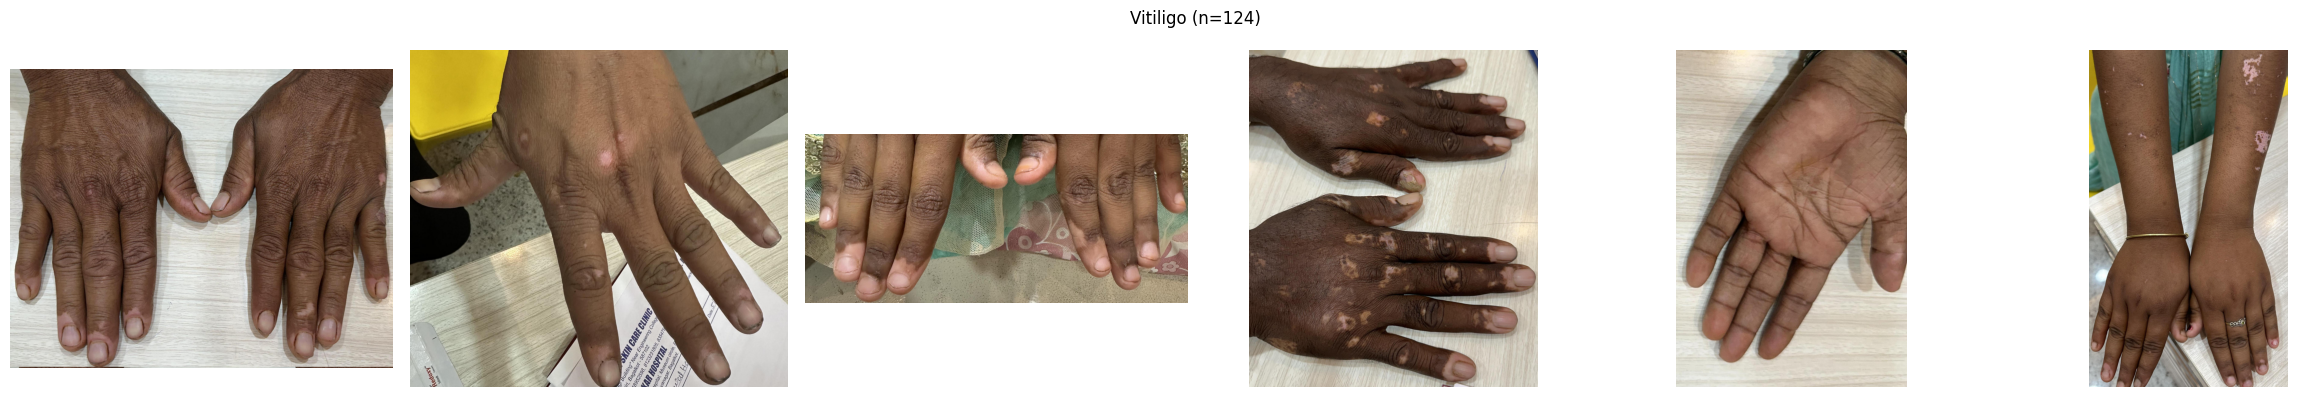

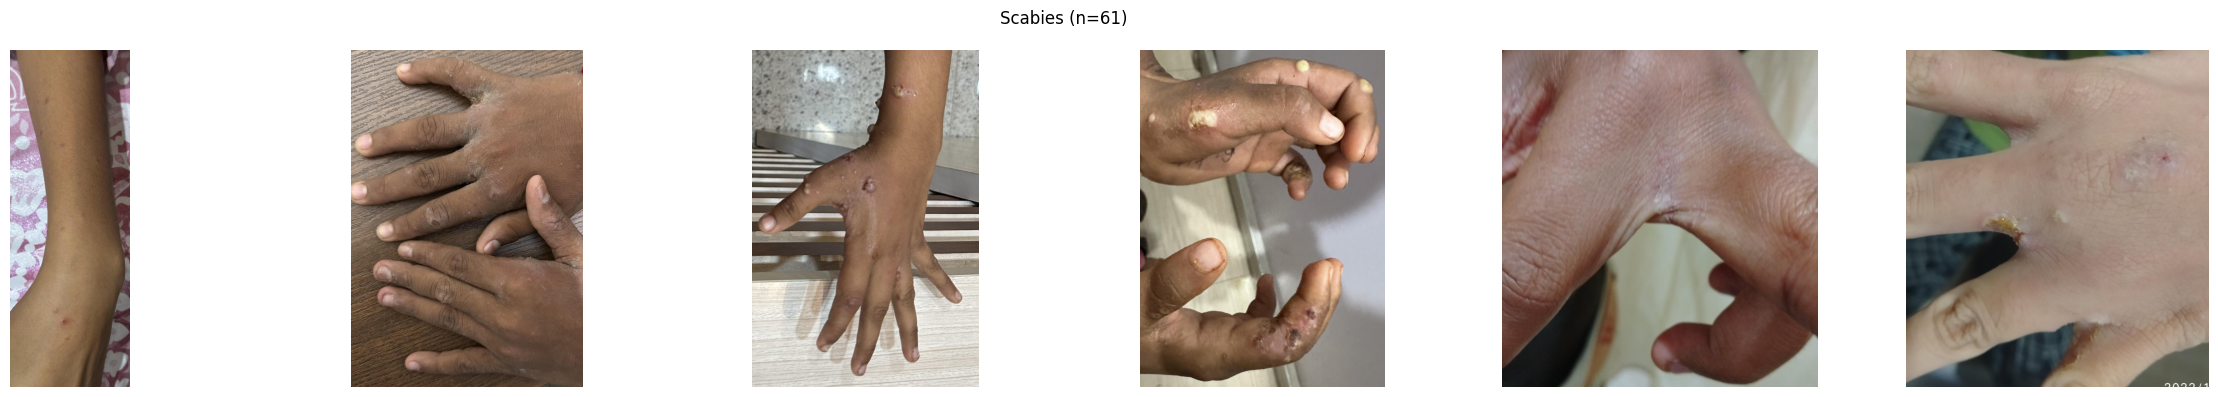

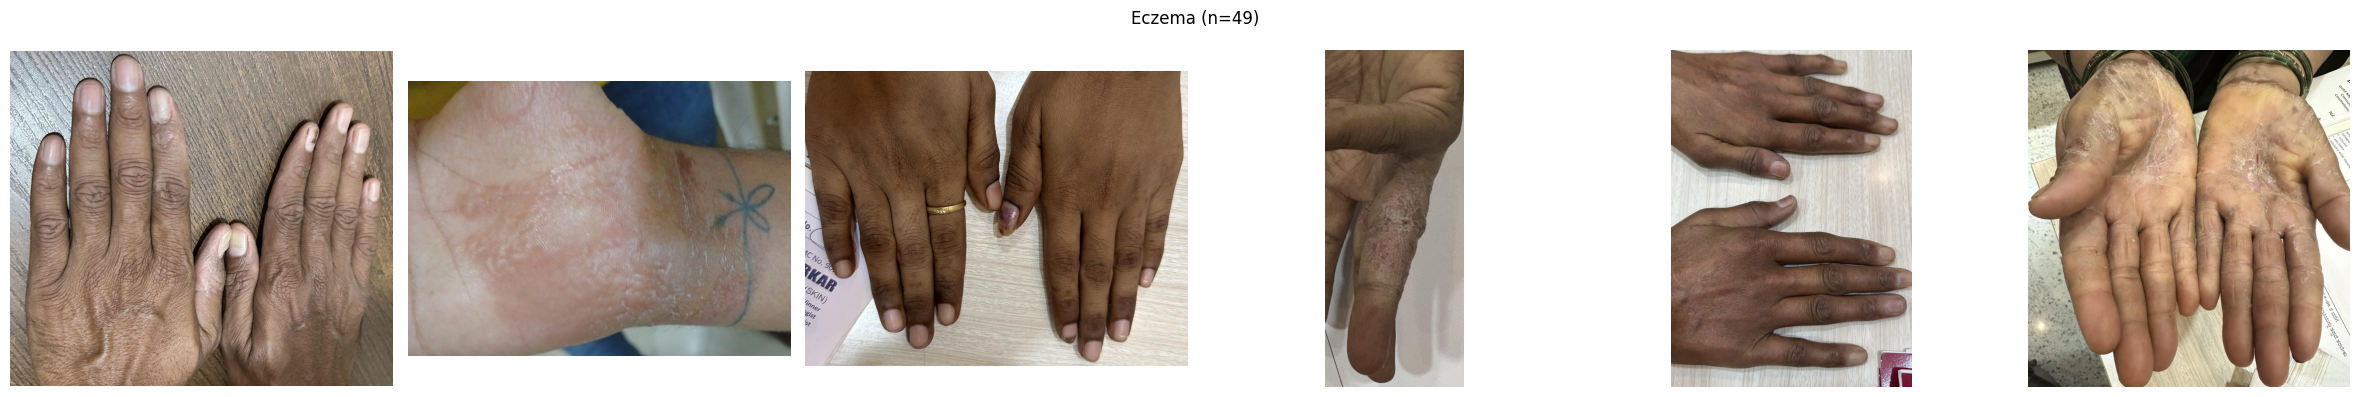

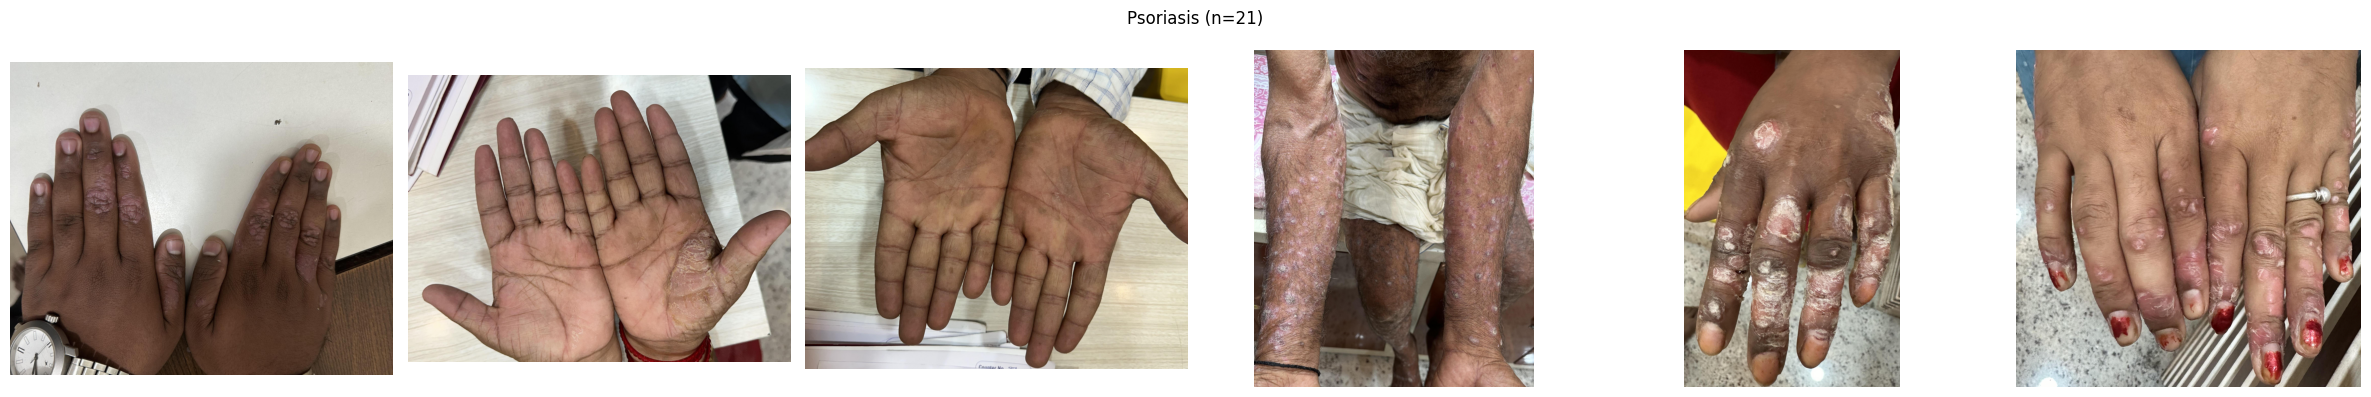

In [9]:
#Step 7 — Visual Verification (Per-Class Sample Review)
import matplotlib.pyplot as plt
import cv2

for cls in ["Vitiligo", "Scabies", "Eczema", "Psoriasis"]:
    cls_df = filtered_df[filtered_df["merged_class"] == cls]
    sample = cls_df.sample(min(6, len(cls_df)), random_state=1)
    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
    if len(sample) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = cv2.imread(row["final_path"])
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis("off")
    fig.suptitle(f"{cls} (n={len(cls_df)})")
    plt.tight_layout()
    plt.show()